In [3]:
# configure auto-reload on import changes (modular changes)
%load_ext autoreload
%autoreload 2

In [4]:
import pickle
import json
import pandas as pd
import numpy as np
from build import FeaturePipeline
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, log_loss, classification_report
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV

In [5]:
fp= FeaturePipeline()


In [6]:
df = pd.read_csv("Train.csv")
df.head()

,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_volume,m1_paybill_total_value,...,m6_withdraw_highest_amount,m6_withdraw_agents,m1_daily_avg_bal,m2_daily_avg_bal,m3_daily_avg_bal,m4_daily_avg_bal,m5_daily_avg_bal,m6_daily_avg_bal,liquidity_stress_next_30d,ID
0,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,8,58372.55,...,0.00,0.0,12488.72,11404.86,12943.70,14157.61,13202.11,4336.98,1,ID_C1DF84C4D2
1,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,0,0.00,...,5191.14,4.0,13677.61,2781.25,5897.59,5416.23,11062.23,4849.68,0,ID_CB8B764D76
2,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,12,41262.86,...,0.00,0.0,7271.09,5364.41,9023.13,13001.02,17107.92,15174.32,1,ID_D40D58FC67
3,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,10,8738.58,...,8965.63,3.0,14331.10,33465.26,2973.45,3577.07,18990.91,8488.26,0,ID_CFD8F26581
4,20535.82,63,F,Northern Highlands,No,MVC,Weekly Earner,0.8959,2,3654.68,...,0.00,0.0,5602.75,8497.49,26252.75,7618.93,9290.65,4214.71,0,ID_20EB501231


In [7]:
new_df, tv_affected_cols = fp.month_over_month_calculation("total_value", df)
new_df

['m1_paybill_total_value', 'm2_paybill_total_value', 'm3_paybill_total_value', 'm4_paybill_total_value', 'm5_paybill_total_value', 'm6_paybill_total_value', 'm1_merchantpay_total_value', 'm2_merchantpay_total_value', 'm3_merchantpay_total_value', 'm4_merchantpay_total_value', 'm5_merchantpay_total_value', 'm6_merchantpay_total_value', 'm1_received_total_value', 'm2_received_total_value', 'm3_received_total_value', 'm4_received_total_value', 'm5_received_total_value', 'm6_received_total_value', 'm1_deposit_total_value', 'm2_deposit_total_value', 'm3_deposit_total_value', 'm4_deposit_total_value', 'm5_deposit_total_value', 'm6_deposit_total_value', 'm1_withdraw_total_value', 'm2_withdraw_total_value', 'm3_withdraw_total_value', 'm4_withdraw_total_value', 'm5_withdraw_total_value', 'm6_withdraw_total_value']


,m1_paybill_total_value_mom,m2_paybill_total_value_mom,m3_paybill_total_value_mom,m4_paybill_total_value_mom,m5_paybill_total_value_mom,m6_paybill_total_value_mom,m1_merchantpay_total_value_mom,m2_merchantpay_total_value_mom,m3_merchantpay_total_value_mom,m4_merchantpay_total_value_mom,...,m3_deposit_total_value_mom,m4_deposit_total_value_mom,m5_deposit_total_value_mom,m6_deposit_total_value_mom,m1_withdraw_total_value_mom,m2_withdraw_total_value_mom,m3_withdraw_total_value_mom,m4_withdraw_total_value_mom,m5_withdraw_total_value_mom,m6_withdraw_total_value_mom
0,58372.550000,-1.000000,2.751840,4034.490000,-1.000000,30817.81,0.000000,0.00000,-1.000000,1.261633,...,0.000000,0.000000,0.000000,0.00,-1.000000,165625.050000,0.000000,0.000000,0.000000,0.00
1,-1.000000,-0.924700,81856.580000,-1.000000,0.324814,10332.48,-0.320495,-0.12302,9219.070000,-1.000000,...,3.323432,67881.300000,-1.000000,211812.24,3.772503,-0.591682,-0.655785,5.949758,-0.614411,90423.40
2,41262.860000,-1.000000,-0.801311,-0.475552,4.603130,11170.94,-0.880449,24262.88000,-1.000000,1.010322,...,-1.000000,0.526599,0.091199,46635.02,-1.000000,259951.260000,-1.000000,0.576066,39266.980000,0.00
3,8738.580000,-1.000000,-0.001689,3.359603,6715.940000,0.00,0.000000,-1.00000,-0.297642,3597.640000,...,167902.170000,0.000000,-1.000000,261151.28,-1.000000,-0.376389,-0.117670,131327.650000,-1.000000,98268.75
4,-0.734089,1.305083,5962.480000,-1.000000,3432.950000,0.00,0.000000,0.00000,-1.000000,17174.520000,...,0.000000,-1.000000,144984.060000,0.00,0.257575,-0.498675,-0.559322,172531.470000,0.000000,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,415.530000,0.00000,0.000000,0.000000,...,5156.080000,0.000000,-1.000000,8746.39,-1.000000,1989.580000,-1.000000,1237.750000,0.000000,0.00
39996,0.000000,0.000000,-1.000000,47583.750000,0.000000,0.00,0.000000,-1.00000,-0.851870,0.778229,...,-1.000000,39018.680000,-1.000000,108784.20,0.372894,-0.833880,137770.350000,-1.000000,-0.563549,143062.99
39997,-0.110714,-0.728474,72591.530000,0.000000,0.000000,0.00,0.000000,0.00000,-1.000000,23605.550000,...,0.000000,-1.000000,-0.750707,201038.68,-0.833111,3.438083,-0.666038,0.518914,-0.746132,49928.94
39998,-1.000000,121622.020000,0.000000,-1.000000,2.087148,24843.41,0.000000,0.00000,0.000000,0.000000,...,-0.660243,22705.020000,0.000000,0.00,0.000000,-1.000000,7.561730,-0.919784,1.404776,22397.81


In [8]:
hg_df, ha_affected_cols = fp.month_over_month_calculation("highest_amount", df)
hg_df

# Instead of transforming highest_amount, Remove those columns with this suffix
def find_and_remove_highest_amt_features(df):
    import re

    pattern = r".+highest_amount$"
    df_cols = df.columns.to_list()
    affected_cols = []
    for s in df_cols:
        match = re.search(pattern, s)
        if match:
            # Extract the specific keyword that triggered the match
            keyword_found = match.group(0)
            # print(f"Match found! String: '{s}' | Keyword: '{keyword_found}'")
            affected_cols.append(keyword_found)
        else:
            pass
    return affected_cols

# hg_amt_cols = find_and_remove_highest_amt_features(df)
# df.drop(columns=hg_amt_cols, inplace=True)

['m1_paybill_highest_amount', 'm2_paybill_highest_amount', 'm3_paybill_highest_amount', 'm4_paybill_highest_amount', 'm5_paybill_highest_amount', 'm6_paybill_highest_amount', 'm1_merchantpay_highest_amount', 'm2_merchantpay_highest_amount', 'm3_merchantpay_highest_amount', 'm4_merchantpay_highest_amount', 'm5_merchantpay_highest_amount', 'm6_merchantpay_highest_amount', 'm1_received_highest_amount', 'm2_received_highest_amount', 'm3_received_highest_amount', 'm4_received_highest_amount', 'm5_received_highest_amount', 'm6_received_highest_amount', 'm1_deposit_highest_amount', 'm2_deposit_highest_amount', 'm3_deposit_highest_amount', 'm4_deposit_highest_amount', 'm5_deposit_highest_amount', 'm6_deposit_highest_amount', 'm1_withdraw_highest_amount', 'm2_withdraw_highest_amount', 'm3_withdraw_highest_amount', 'm4_withdraw_highest_amount', 'm5_withdraw_highest_amount', 'm6_withdraw_highest_amount']


In [9]:
bal_df = fp.bal_avg_mom_calculations(df)
bal_df

,m1_m2_bal_diff_raw,m1_m2_bal_diff_pct,m2_m3_bal_diff_raw,m2_m3_bal_diff_pct,m3_m4_bal_diff_raw,m3_m4_bal_diff_pct,m4_m5_bal_diff_raw,m4_m5_bal_diff_pct,m5_m6_bal_diff_raw,m5_m6_bal_diff_pct
0,1083.86,0.095027,-1538.84,-0.118878,-1213.91,-0.085737,955.50,0.072369,8865.13,2.043608
1,10896.36,3.916384,-3116.34,-0.528319,481.36,0.088857,-5646.00,-0.510339,6212.55,1.280759
2,1906.68,0.355365,-3658.72,-0.405437,-3977.89,-0.305944,-4106.90,-0.240044,1933.60,0.127417
3,-19134.16,-0.571745,30491.81,10.251243,-603.62,-0.168700,-15413.84,-0.811600,10502.65,1.237169
4,-2894.74,-0.340618,-17755.26,-0.676294,18633.82,2.445406,-1671.72,-0.179916,5075.94,1.204053
...,...,...,...,...,...,...,...,...,...,...
39995,-577.33,-0.264363,1462.25,2.026400,-166.45,-0.187433,83.28,0.103483,-1809.78,-0.692196
39996,5550.69,0.935945,-3339.06,-0.360215,3046.77,0.489609,-1142.47,-0.155115,-6.12,-0.000830
39997,-2170.07,-0.199613,104.35,0.009692,-973.32,-0.082904,-501.63,-0.040976,7229.64,1.442365
39998,3152.77,1.248721,-10781.71,-0.810258,4606.79,0.529533,6256.70,2.561051,-8870.51,-0.784062


In [10]:
# Combine all dfs
all_df = pd.concat([new_df, hg_df, bal_df], axis=1)
all_df

,m1_paybill_total_value_mom,m2_paybill_total_value_mom,m3_paybill_total_value_mom,m4_paybill_total_value_mom,m5_paybill_total_value_mom,m6_paybill_total_value_mom,m1_merchantpay_total_value_mom,m2_merchantpay_total_value_mom,m3_merchantpay_total_value_mom,m4_merchantpay_total_value_mom,...,m1_m2_bal_diff_raw,m1_m2_bal_diff_pct,m2_m3_bal_diff_raw,m2_m3_bal_diff_pct,m3_m4_bal_diff_raw,m3_m4_bal_diff_pct,m4_m5_bal_diff_raw,m4_m5_bal_diff_pct,m5_m6_bal_diff_raw,m5_m6_bal_diff_pct
0,58372.550000,-1.000000,2.751840,4034.490000,-1.000000,30817.81,0.000000,0.00000,-1.000000,1.261633,...,1083.86,0.095027,-1538.84,-0.118878,-1213.91,-0.085737,955.50,0.072369,8865.13,2.043608
1,-1.000000,-0.924700,81856.580000,-1.000000,0.324814,10332.48,-0.320495,-0.12302,9219.070000,-1.000000,...,10896.36,3.916384,-3116.34,-0.528319,481.36,0.088857,-5646.00,-0.510339,6212.55,1.280759
2,41262.860000,-1.000000,-0.801311,-0.475552,4.603130,11170.94,-0.880449,24262.88000,-1.000000,1.010322,...,1906.68,0.355365,-3658.72,-0.405437,-3977.89,-0.305944,-4106.90,-0.240044,1933.60,0.127417
3,8738.580000,-1.000000,-0.001689,3.359603,6715.940000,0.00,0.000000,-1.00000,-0.297642,3597.640000,...,-19134.16,-0.571745,30491.81,10.251243,-603.62,-0.168700,-15413.84,-0.811600,10502.65,1.237169
4,-0.734089,1.305083,5962.480000,-1.000000,3432.950000,0.00,0.000000,0.00000,-1.000000,17174.520000,...,-2894.74,-0.340618,-17755.26,-0.676294,18633.82,2.445406,-1671.72,-0.179916,5075.94,1.204053
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,415.530000,0.00000,0.000000,0.000000,...,-577.33,-0.264363,1462.25,2.026400,-166.45,-0.187433,83.28,0.103483,-1809.78,-0.692196
39996,0.000000,0.000000,-1.000000,47583.750000,0.000000,0.00,0.000000,-1.00000,-0.851870,0.778229,...,5550.69,0.935945,-3339.06,-0.360215,3046.77,0.489609,-1142.47,-0.155115,-6.12,-0.000830
39997,-0.110714,-0.728474,72591.530000,0.000000,0.000000,0.00,0.000000,0.00000,-1.000000,23605.550000,...,-2170.07,-0.199613,104.35,0.009692,-973.32,-0.082904,-501.63,-0.040976,7229.64,1.442365
39998,-1.000000,121622.020000,0.000000,-1.000000,2.087148,24843.41,0.000000,0.00000,0.000000,0.000000,...,3152.77,1.248721,-10781.71,-0.810258,4606.79,0.529533,6256.70,2.561051,-8870.51,-0.784062


In [11]:
avg_cols = fp.get_bal_avg_cols(all_df)
avg_cols

['m1_daily_avg_bal',
 'm2_daily_avg_bal',
 'm3_daily_avg_bal',
 'm4_daily_avg_bal',
 'm5_daily_avg_bal',
 'm6_daily_avg_bal']

In [12]:
def remove_correlated_features(df):# Create a correlation matrix for your engineered features
    corr_matrix = all_df.corr().abs()

    # Select the upper triangle of the matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Find features with a correlation higher than 0.80
    to_drop = [column for column in upper.columns if any(upper[column] > 0.80)]

    # Safely drop only the strictly identical redundancies
    df_cleaned = df.drop(columns=to_drop)
    print(f"Removed {len(to_drop)} heavily redundant features.")
    return df_cleaned

df_cleaned = remove_correlated_features(all_df)


Removed 0 heavily redundant features.


In [13]:
# Join all_df with train df
train_df = pd.concat([df, df_cleaned], axis=1)
# train_df=df

In [14]:
# Remove transformed features
# transformed_cols = ha_affected_cols + tv_affected_cols + avg_cols
# train_df = train_df.drop(columns=transformed_cols)

In [15]:
# Incorporate aggregations (from another tested notebook)
from agg import build_all_channel_aggregates, compute_liquidity_signals
out = build_all_channel_aggregates(df)
sig = compute_liquidity_signals(df, out)
sig.head(2)

,avg_balance_6m,balance_trend,balance_volatility,withdraw_share_of_outflow,paybill_share_of_outflow,total_outflow_value,total_inflow_value,outflow_to_inflow_ratio,outflow_channel_entropy,withdraw_active_months,paybill_active_months,withdraw_share_trend,paybill_share_trend
0,11422.330,8151.74,0.313963,0.498137,0.325910,332489.28,590474.93,0.563088,1.106951,1,4,0.622915,-0.246824
1,7280.765,8827.93,0.572149,0.732322,0.126699,884314.06,1286319.71,0.687476,0.838202,6,4,-0.205591,0.143456


In [16]:
print(sig.shape)

# Combine train_df and sig
train_df = pd.concat([train_df, sig], axis=1)
train_df.shape

(40000, 13)


(40000, 267)

In [17]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Columns: 267 entries, arpu to paybill_share_trend
dtypes: float64(215), int64(46), str(6)
memory usage: 81.5 MB


In [18]:
remove_correlated_features(train_df)

Removed 0 heavily redundant features.


,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_volume,m1_paybill_total_value,...,withdraw_share_of_outflow,paybill_share_of_outflow,total_outflow_value,total_inflow_value,outflow_to_inflow_ratio,outflow_channel_entropy,withdraw_active_months,paybill_active_months,withdraw_share_trend,paybill_share_trend
0,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,8,58372.55,...,0.498137,0.325910,332489.28,590474.93,0.563088,1.106951,1,4,0.622915,-0.246824
1,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,0,0.00,...,0.732322,0.126699,884314.06,1286319.71,0.687476,0.838202,6,4,-0.205591,0.143456
2,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,12,41262.86,...,0.585689,0.250385,616548.03,555448.07,1.110001,1.059653,3,5,0.250741,-0.328409
3,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,10,8738.58,...,0.554833,0.098238,752895.07,815487.78,0.923245,0.973114,4,4,-0.040000,0.017760
4,20535.82,63,F,Northern Highlands,No,MVC,Weekly Earner,0.8959,2,3654.68,...,0.497002,0.039797,673262.10,497169.23,1.354191,0.931015,4,4,0.085850,0.069407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,1554.59,30,F,Southern Highlands,No,LVC,Weekly Earner,0.1637,0,0.00,...,0.552932,0.000000,5836.76,15317.03,0.381063,0.997344,2,0,0.466544,0.000000
39996,26548.53,57,M,Islander,No,MVC,Weekly Earner,0.7843,0,0.00,...,0.605369,0.072453,656756.83,597292.01,1.099557,1.053316,5,1,0.022202,-0.137735
39997,26548.53,57,M,Islander,No,MVC,Weekly Earner,0.7843,8,17528.25,...,0.195291,0.176411,622580.32,747442.26,0.832948,1.257168,6,3,-0.128052,0.359573
39998,26548.53,57,M,Islander,No,MVC,Weekly Earner,0.7843,0,0.00,...,0.138601,0.263077,848271.66,420887.18,2.015437,1.036740,4,3,-0.338740,-0.310524


In [19]:
# Check anywhere in dataset with presence of np.inf
train_df.isin([np.inf, -np.inf]).any().sum()

np.int64(0)

In [20]:
# Remove volume feature
volume_cols = [col for col in train_df.columns if "volume" in col]
train_df.drop(columns=volume_cols, inplace=True)
len(volume_cols)

42

In [21]:
# Remove some features that I consider it unuseful
unuseful_cols = [
    col for col in train_df.columns.to_list() 
    if 'agent' in col or 'senders' in col 
    or 'recipients' in col or 'merchants' in col 
    or 'companies' in col
    or 'bank_banks' in col
]
train_df.drop(columns=unuseful_cols, inplace=True)
len(unuseful_cols)

42

In [22]:
X_t, y = fp.transform(train_df)
X_t.head(2)

,arpu,age,x_90_d_activity_rate,m1_paybill_total_value,m1_paybill_highest_amount,m2_paybill_total_value,m2_paybill_highest_amount,m3_paybill_total_value,m3_paybill_highest_amount,m4_paybill_total_value,...,region_Islander,region_Lake Zone (Northwest),region_Northern Highlands,region_Southern Highlands,region_Western Zone,smartphone_Yes,segment_LVC,segment_MVC,earning_pattern_Monthly Earner,earning_pattern_Weekly Earner
0,2653.88,47,0.6905,58372.55,5352.41,0.00,0.00,15136.76,4527.39,4034.49,...,False,False,False,False,False,True,False,True,True,False
1,2653.88,47,0.6905,0.00,0.00,6163.78,5094.88,81856.58,4509.02,0.00,...,False,False,False,False,False,True,False,True,True,False


In [23]:
from build import ModelPipeline
pipeline = ModelPipeline()

In [24]:
X_train, y_train, X_val, y_val, pos_weight = pipeline.split_dataset(train_df)

Submitted Dataset Shape: (40000, 183), Val Size: 0.2


Dataset Split: Train = 32000 rows, Val = 8000 rows


In [25]:
def tune_lgbm(X_train, y_train, random_state=42):
    """Tunes LightGBM hyperparameters using Stratified K-Fold to balance Precision and Recall."""    
    pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

    # Currently best performer - Sept 2
    param_grid = {
        # 1. Direct control over positive class weight (scale down to boost precision)
        "scale_pos_weight": [
            # pos_weight * 0.5,
            # pos_weight * 0.75,
            # pos_weight,
            2.8333333333333335
        ],
        # 2. Tree structural constraints (controls overfitting/false positives)
        "max_depth": [7],
        # "max_depth": [6],
        "num_leaves": [15],
        # "min_data_in_leaf": [50],
        # 3. Regularization & Subsampling
        "colsample_bytree": [0.5],
        "reg_alpha": [10],
        "reg_lambda": [20],
        "learning_rate": [0.05],
        # "n_estimators": [400],
        "n_estimators": [1000],
    }

    lgb = LGBMClassifier(
        random_state=random_state,
        importance_type="gain",
        verbosity=-1,
        device="cpu",
        n_jobs=1,
        metric="logloss",
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    # Target F1 or Average Precision (PR-AUC) instead of generic accuracy
    grid = GridSearchCV(
        estimator=lgb,
        param_grid=param_grid,
        scoring="roc_auc",  # Or 'average_precision' / 'roc_auc'
        cv=cv,
        n_jobs=4,
        verbose=1,
    )

    grid.fit(X_train, y_train)

    print(f"Best Parameters: {grid.best_params_}")
    print(f"Best CV Score: {grid.best_score_:.4f}")

    lgb_model = grid.best_estimator_
    return lgb_model

In [26]:
# Remove some features and see how model performs (Removing these columns improved the ROC and LOG LOSS)
x_cols = ["m1_net_flow", "m2_net_flow", "m3_net_flow", "m4_net_flow", "m5_net_flow", "m6_net_flow",]
X_train = X_train.drop(columns=x_cols)
X_val = X_val.drop(columns=x_cols)

In [27]:
# Get dulicated columns and remain with one of them
X_train, X_val = X_train.loc[:, ~X_train.columns.duplicated()], X_val.loc[:, ~X_val.columns.duplicated()]

In [28]:
# Load and remove previously features which were not useful based on feature importance gains
with open("non_performing_features.json", "r") as f:
    non_performing_features = json.load(f)

with open("A_non_performing_features2.json", "r") as f:
    non_performing_features2 = json.load(f)

In [29]:

X_train = X_train.drop(columns=non_performing_features)
X_val = X_val.drop(columns=non_performing_features)


# Remvoe the version2 which were based on the cummulative and relative gain
X_train = X_train.drop(columns=non_performing_features2)
X_val = X_val.drop(columns=non_performing_features2)

In [30]:
# Remove all month over month features (which were manually calculated), they seem to add nothing to the model
def find_and_remove_mom_features(df):
    import re

    pattern = r".+_mom$"
    mom_features = [col for col in df.columns if re.search(pattern, col)]
    df = df.drop(columns=mom_features)
    return df


In [31]:
print("Before change: ", X_train.shape)
X_train = find_and_remove_mom_features(X_train)
X_val = find_and_remove_mom_features(X_val)
print("After change: ", X_train.shape)

Before change:  (32000, 184)
After change:  (32000, 127)


In [38]:
import json
with open("ALL127COLUMNS.json", "w") as f:
    json.dump(X_train.columns.tolist(), f)

In [34]:
model = tune_lgbm(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Best Parameters: {'colsample_bytree': 0.5, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 1000, 'num_leaves': 15, 'reg_alpha': 10, 'reg_lambda': 20, 'scale_pos_weight': 2.8333333333333335}
Best CV Score: 0.8991


In [37]:
len(X_train.columns)

127

In [35]:
train_m_preds = model.predict_proba(X_train)[:, 1]
val_m_preds = model.predict_proba(X_val)[:, 1]
print("Train ROC: ", roc_auc_score(y_train, train_m_preds))
print("Val ROC: ", roc_auc_score(y_val, val_m_preds))
print("Val Log Loss: ", log_loss(y_val, val_m_preds))


Train ROC:  0.9759719362745098
Val ROC:  0.8942272058823529
Val Log Loss:  0.28871048981772096


In [94]:
train_m_preds = model.predict_proba(X_train)[:, 1]
val_m_preds = model.predict_proba(X_val)[:, 1]
print("Train ROC: ", roc_auc_score(y_train, train_m_preds))
print("Val ROC: ", roc_auc_score(y_val, val_m_preds))
print("Val Log Loss: ", log_loss(y_val, val_m_preds))

Train ROC:  0.9759719362745098
Val ROC:  0.8942272058823529
Val Log Loss:  0.28871048981772096


In [30]:
0.2873960555222003 - 0.28979341873558817

-0.0023973632133878486

              precision    recall  f1-score   support

           0       0.94      0.92      0.93      6800
           1       0.58      0.64      0.61      1200

    accuracy                           0.88      8000
   macro avg       0.76      0.78      0.77      8000
weighted avg       0.88      0.88      0.88      8000



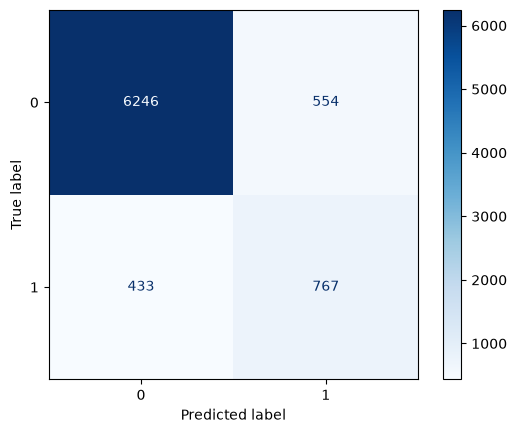

In [39]:
cm = confusion_matrix(y_val, val_m_preds > 0.5)

# First show the classification report
print(classification_report(y_val, val_m_preds > 0.5), end="\n=======\n")
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot(cmap="Blues");

In [40]:
ft_dict = dict(zip(model.feature_name_, model.feature_importances_))
feat_imp = {
    "Features": [],
    "Score": []
}

for ft, sc in ft_dict.items():
    feat_imp['Features'].append(ft)
    feat_imp['Score'].append(sc)

In [41]:
ft_imp_df = pd.DataFrame(data=feat_imp).sort_values(by="Score", ascending=False)
# ft_imp_df.set_index("Features", inplace=True)
ft_imp_df

,Features,Score
115,bal_slope_6m,34762.320169
114,net_coverage_recent_3m,25741.609949
117,inflow_slope_6m,23104.711432
112,inflow_drift_3m,12328.930239
78,m3_m4_bal_diff_pct,11094.878855
...,...,...
23,m2_transfer_from_bank_total_value,327.619080
4,m1_paybill_highest_amount,324.831882
30,m2_mm_send_total_value,324.642510
25,m3_transfer_from_bank_highest_amount,297.779539


In [42]:
# Find total gains
total_gain = ft_imp_df["Score"].sum()
# Find cumulative gain
ft_imp_df["Cumulative Gain"] = ft_imp_df["Score"].cumsum()
# Find relative gain
ft_imp_df["Relative Gain"] = ft_imp_df["Cumulative Gain"] / total_gain

# Find running difference on relative gain to check big contributors
ft_imp_df["Running Difference"] = ft_imp_df["Relative Gain"].diff()

ft_imp_df

,Features,Score,Cumulative Gain,Relative Gain,Running Difference
115,bal_slope_6m,34762.320169,34762.320169,0.112314,NaN
114,net_coverage_recent_3m,25741.609949,60503.930118,0.195482,0.083169
117,inflow_slope_6m,23104.711432,83608.641550,0.270132,0.074649
112,inflow_drift_3m,12328.930239,95937.571789,0.309965,0.039834
78,m3_m4_bal_diff_pct,11094.878855,107032.450644,0.345812,0.035847
...,...,...,...,...,...
23,m2_transfer_from_bank_total_value,327.619080,308304.894879,0.996104,0.001059
4,m1_paybill_highest_amount,324.831882,308629.726762,0.997154,0.001050
30,m2_mm_send_total_value,324.642510,308954.369272,0.998202,0.001049
25,m3_transfer_from_bank_highest_amount,297.779539,309252.148811,0.999165,0.000962


In [38]:
# This was used when still using raw score (without cumulative and relative gain)
# Get non-performing features and store them into json file then go up in training cell, remove them and retrain the model
# non_performing_features = ft_imp_df[ft_imp_df["Score"] < 100].index

# with open("non_performing_features2.json", "w") as f:
#     # Respect how 
#     json.dump(non_performing_features.tolist(), f)


# Export based on relative gain and 99% cutoff
non_performing_features = ft_imp_df[ft_imp_df["Relative Gain"] > 0.99]['Features']

with open("A_non_performing_features2.json", "w") as f:
    # Respect how 
    json.dump(non_performing_features.tolist(), f)

In [118]:
ft_imp_df.to_json("feature_importance_sorted.json")

In [32]:
model = pipeline.fit_and_evaluate(
    raw_df=train_df,
    version=5
)

Reading dataset from: 
Submitted Dataset Shape: (40000, 170), Val Size: 0.2
Dataset Split: Train = 32000 rows, Val = 8000 rows
Features generated: 153 columns. Imbalance Ratio: 5.67
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Parameters: {'colsample_bytree': 0.5, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'num_leaves': 31, 'reg_alpha': 10, 'reg_lambda': 20, 'scale_pos_weight': 2.8333333333333335}
Best CV Score: 0.8951
--- Training CatBoost Classifier ---
--- Training Regularized Logistic Regression ---

[SUCCESS] All Models Fitted!

================ VALIDATION RESULTS ================
Validation ROC-AUC Score: 0.886955

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92      6800
           1       0.56      0.61      0.59      1200

    accuracy                           0.87      8000
   macro avg       0.75      0.77      0.76      8000
weighted avg       0.88      0.87      0

In [24]:
with open("training_metrics_v5_f153.pkl", "rb") as f:
    recent_tr = pickle.load(f)
type(recent_tr)

dict

In [95]:
calibrated_lgb = CalibratedClassifierCV(
    estimator=model, method='isotonic', cv=5
)

In [96]:
# calibrated_lgb.fit(X_train, y_train)
calibrated_lgb.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LGBMClassifie... verbosity=-1)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...x7594378201a0>, <s

In [45]:
val_pred=calibrated_lgb.predict_proba(X_val)[:, 1]
val_pred

array([0.00869951, 0.06999349, 0.75492415, ..., 0.00309922, 0.0045118 ,
       0.11270173], shape=(8000,))

In [46]:
print(roc_auc_score(y_val, val_pred))
print(log_loss(y_val, val_pred))

0.8944926470588234
0.26572430555966015


In [35]:
p = pipeline.fit_and_evaluate(
    raw_df=train_df,
    version=5
)

Reading dataset from: 
Submitted Dataset Shape: (40000, 170), Val Size: 0.2
Dataset Split: Train = 32000 rows, Val = 8000 rows
Features generated: 149 columns. Imbalance Ratio: 5.67
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Parameters: {'colsample_bytree': 0.5, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 1000, 'num_leaves': 15, 'reg_alpha': 10, 'reg_lambda': 20, 'scale_pos_weight': 2.8333333333333335, 'subsample': 1.0}
Best CV Score: 0.8926
--- Training CatBoost Classifier ---
--- Training Regularized Logistic Regression ---

[SUCCESS] All Models Fitted!

================ VALIDATION RESULTS ================
Validation ROC-AUC Score: 0.887217

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92      6800
           1       0.57      0.61      0.59      1200

    accuracy                           0.87      8000
   macro avg       0.75      0.77      0.76      8000
weighted avg       0

In [124]:
calibrated_lgb = CalibratedClassifierCV(
    estimator=p.lgb_model, method='isotonic', cv=None, ensemble=False
)

In [125]:
calibrated_lgb.fit(X_train, y_train)
# calibrated_lgb.fit(X_val, y_val)
val_pred=calibrated_lgb.predict_proba(X_val)[:, 1]
val_pred

array([0.00941006, 0.08029648, 0.77777778, ..., 0.00620767, 0.00941006,
       0.08029648], shape=(8000,))

In [126]:
print(roc_auc_score(y_val, val_pred))
print(log_loss(y_val, val_pred))

0.8853671568627451
0.27937260543090703


In [151]:
# Pass cv=5 to train base estimators on 5 folds and calibrate out-of-fold predictions
calibrated_lgb = CalibratedClassifierCV(
    estimator=p.lgb_model, method="isotonic", cv=5
)
calibrated_lgb.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LGBMClassifie... verbosity=-1)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...x73eaf8ce4410>, <s

In [152]:
# calibrated_lgb.fit(X_val, y_val)
val_pred=calibrated_lgb.predict_proba(X_val)[:, 1]
val_pred

array([0.00846171, 0.10629585, 0.75274165, ..., 0.00129367, 0.00923352,
       0.07955547], shape=(8000,))

In [153]:
print(roc_auc_score(y_val, val_pred))
print(log_loss(y_val, val_pred))

0.8852055759803922
0.27483091429350665


In [110]:
recent_tr.keys()

dict_keys(['X_train', 'y_train', 'X_val', 'y_val'])

In [69]:
# from xgboost import XGBClassifier

# pipeline = XGBClassifier()
# pipeline.load_model("model_pipeline_v2_f149.json")
# pipeline
import lightgbm as lgb
bst = lgb.Booster(model_file="model_pipeline_v2_f149.txt")
bst

# lgb.Dataset(, study.best_params)

In [114]:
test_df = pd.read_csv("Test.csv")
# train_df = pd.read_csv("Train.csv")

In [115]:
new_tdf, tv_cols = fp.month_over_month_calculation("total_value", test_df)
hg_tdf, ha_cols = fp.month_over_month_calculation("highest_amount", test_df)
bal_tdf = fp.bal_avg_mom_calculations(test_df)
# Combine all dfs
all_tdf = pd.concat([test_df, new_tdf, hg_tdf, bal_tdf], axis=1)
# all_tdf = test_df


['m1_paybill_total_value', 'm2_paybill_total_value', 'm3_paybill_total_value', 'm4_paybill_total_value', 'm5_paybill_total_value', 'm6_paybill_total_value', 'm1_merchantpay_total_value', 'm2_merchantpay_total_value', 'm3_merchantpay_total_value', 'm4_merchantpay_total_value', 'm5_merchantpay_total_value', 'm6_merchantpay_total_value', 'm1_received_total_value', 'm2_received_total_value', 'm3_received_total_value', 'm4_received_total_value', 'm5_received_total_value', 'm6_received_total_value', 'm1_deposit_total_value', 'm2_deposit_total_value', 'm3_deposit_total_value', 'm4_deposit_total_value', 'm5_deposit_total_value', 'm6_deposit_total_value', 'm1_withdraw_total_value', 'm2_withdraw_total_value', 'm3_withdraw_total_value', 'm4_withdraw_total_value', 'm5_withdraw_total_value', 'm6_withdraw_total_value']
['m1_paybill_highest_amount', 'm2_paybill_highest_amount', 'm3_paybill_highest_amount', 'm4_paybill_highest_amount', 'm5_paybill_highest_amount', 'm6_paybill_highest_amount', 'm1_merc

In [116]:
all_tdf.head()

,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_volume,m1_paybill_total_value,...,m1_m2_bal_diff_raw,m1_m2_bal_diff_pct,m2_m3_bal_diff_raw,m2_m3_bal_diff_pct,m3_m4_bal_diff_raw,m3_m4_bal_diff_pct,m4_m5_bal_diff_raw,m4_m5_bal_diff_pct,m5_m6_bal_diff_raw,m5_m6_bal_diff_pct
0,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,0,0.00,...,-2118.02,-0.225524,-7849.20,-0.455270,4250.03,0.327158,1755.77,0.156277,-5227.24,-0.317530
1,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,14,89420.67,...,6575.66,2.216034,-5707.58,-0.657943,-2952.52,-0.253928,7462.84,1.791983,-814.71,-0.163620
2,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,0,0.00,...,-7602.31,-0.704856,5169.95,0.920629,-1220.29,-0.178510,-3227.62,-0.320723,7107.71,2.404608
3,20535.82,63,F,Northern Highlands,No,MVC,Weekly Earner,0.8959,0,0.00,...,-17486.72,-0.530866,29256.44,7.942415,-4888.26,-0.570270,-117.17,-0.013485,-939.55,-0.097580
4,20535.82,63,F,Northern Highlands,No,MVC,Weekly Earner,0.8959,0,0.00,...,3758.07,0.515117,-25038.07,-0.774366,28289.20,6.994607,-7637.34,-0.653783,4354.31,0.594245


In [117]:
# Remove affected cols
# all_tdf = all_tdf.drop(columns=transformed_cols)
all_tdf.drop(columns=volume_cols, inplace=True)

In [118]:
# Remove some features that I consider it unuseful
all_tdf.drop(columns=unuseful_cols, inplace=True)

In [119]:
agg_tdf = build_all_channel_aggregates(test_df)
sig_tdf = compute_liquidity_signals(test_df, agg_tdf)
sig_tdf.head(2)

,avg_balance_6m,balance_trend,balance_volatility,withdraw_share_of_outflow,paybill_share_of_outflow,total_outflow_value,total_inflow_value,outflow_to_inflow_ratio,outflow_channel_entropy,withdraw_active_months,paybill_active_months,withdraw_share_trend,paybill_share_trend
0,12431.301667,-9188.66,0.315607,0.488849,0.153392,374654.18,1103003.80,0.339667,1.241177,3,3,0.140257,-0.075664
1,6991.738333,4563.69,0.491602,0.666079,0.134375,1067063.15,914074.81,1.167370,0.989123,6,3,0.080225,0.021918


In [120]:
# Combine all_tdf with sig_tdf
all_tdf = pd.concat([all_tdf, sig_tdf], axis=1)
all_tdf.head(2)

,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_total_value,m1_paybill_highest_amount,...,withdraw_share_of_outflow,paybill_share_of_outflow,total_outflow_value,total_inflow_value,outflow_to_inflow_ratio,outflow_channel_entropy,withdraw_active_months,paybill_active_months,withdraw_share_trend,paybill_share_trend
0,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,0.00,0.00,...,0.488849,0.153392,374654.18,1103003.80,0.339667,1.241177,3,3,0.140257,-0.075664
1,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,89420.67,4231.17,...,0.666079,0.134375,1067063.15,914074.81,1.167370,0.989123,6,3,0.080225,0.021918


In [121]:
X, _ = fp.transform(all_tdf)

In [130]:
X.drop(columns=x_cols, inplace=True)

In [126]:
X = find_and_remove_mom_features(X)
print(X.shape)

# X = X.drop(columns=non_performing_features)


# Remvoe the version2 which were based on the cummulative and relative gain
X = X.drop(columns=non_performing_features2)


(30000, 180)


In [127]:
# Remove duplicated columns
X = X.loc[:, ~X.columns.duplicated()]

In [131]:
X.shape

(30000, 141)

In [76]:
# In-notebook predictions
# test_probs = pipeline.predict_proba(X)[:, 1]
test_probs = calibrated_lgb.predict_proba(X)[:, 1]

In [77]:
test_probs

array([0.01931138, 0.08055309, 0.01381456, ..., 0.1904632 , 0.00457016,
       0.40854353], shape=(30000,))

In [78]:
submission = pd.DataFrame({"ID": test_df["ID"], "Target": test_probs})
submission.to_csv("submission.csv", index=False)
print("Submission file saved!")

submission.head()


Submission file saved!


,ID,Target
0,ID_ED91AC7A28,0.019311
1,ID_29975A9C7E,0.080553
2,ID_F59CE25650,0.013815
3,ID_E875F68D1A,0.000651
4,ID_2902B1C0D0,0.008665


In [82]:
# train_preds = pipeline.predict_proba(X_t)[:, 1]
# X_t.head()
train_preds = calibrated_lgb.predict_proba(X_t.loc[:, ~X_t.columns.duplicated()])[:, 1]
train_preds

array([0.58993479, 0.00065147, 0.4807351 , ..., 0.01501185, 0.07979368,
       0.08383495], shape=(40000,))

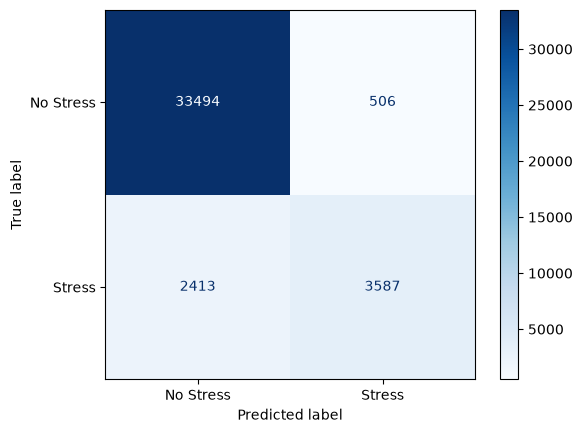

In [83]:
# Change y_pred to int
y_pred = (train_preds > 0.5).astype(int)
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["No Stress", "Stress"]
)
disp.plot(cmap="Blues")
plt.show()

In [ ]:
log_loss(y, train_preds)

0.18552630358765496

In [85]:
roc_auc_score(y, train_preds)

0.9618230686274509